In [84]:
import yfinance as yf
import pandas as pd
import numpy as np
import json
import warnings
import datetime
import sklearn
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

In [43]:
df_analysis = pd.read_csv(r"c:\Users\matth\PhD\Spring 2026\SSIE-605 Applied Multivariate Data Analysis\Project\matt_g_full_analysis_sp500_2020_survivors")
print(df_analysis.isnull().sum())

#shows a lot of NA's on LCTQ (liabilities) ratio, will see how Op_Cash_Flow_Ratio Current_Ratio Rtrn_On_Cptl_Emplyd are significant or not

Unnamed: 0                      0
gvkey                           0
tic                             0
cal_yr                          0
cal_qtr                         0
Sector_Name                     0
gdp_growth                      0
inflation                       0
Outperform                      0
Market_Cap                      8
Dividend_Profit_After_Tax       1
Op_Cash_Flow_Ratio           1403
Earnings_Per_share              1
Price_to_Earnings               9
Price_to_Sales                  9
Current_Ratio                1403
Profit_Margin                   1
Rtrn_On_Assets                  1
Rtrn_On_Cptl_Emplyd          1412
Rtrn_On_Equity                  1
Debt_to_Asset                   0
Debt_to_Equity                  0
Interest_Coverage             596
Fixed_Asset_Turnover          479
Book_Value_Per_Share            0
Sales_to_Cash_Flow              1
Net_Sales_Increase            406
Cash_EPS                      742
Price_to_Cash_Earnings        750
PBITDS        

In [44]:
#taking the log transform of marketcap prior to analysis 
df_analysis['Market_Cap'] = np.log(df_analysis['Market_Cap'])
df_analysis.replace([np.inf, -np.inf], np.nan, inplace=True)
df_analysis = df_analysis.dropna()  #may need to investigate the large amount of NA's present

In [45]:
df_analysis.shape

(6033, 32)

In [46]:
df_analysis.columns

Index(['Unnamed: 0', 'gvkey', 'tic', 'cal_yr', 'cal_qtr', 'Sector_Name',
       'gdp_growth', 'inflation', 'Outperform', 'Market_Cap',
       'Dividend_Profit_After_Tax', 'Op_Cash_Flow_Ratio', 'Earnings_Per_share',
       'Price_to_Earnings', 'Price_to_Sales', 'Current_Ratio', 'Profit_Margin',
       'Rtrn_On_Assets', 'Rtrn_On_Cptl_Emplyd', 'Rtrn_On_Equity',
       'Debt_to_Asset', 'Debt_to_Equity', 'Interest_Coverage',
       'Fixed_Asset_Turnover', 'Book_Value_Per_Share', 'Sales_to_Cash_Flow',
       'Net_Sales_Increase', 'Cash_EPS', 'Price_to_Cash_Earnings', 'PBITDS',
       'Sales_to_Net_Assets', 'Price_to_Book'],
      dtype='object')

In [47]:
df_analysis

,Unnamed: 0,gvkey,tic,cal_yr,cal_qtr,Sector_Name,gdp_growth,inflation,Outperform,Market_Cap,...,Interest_Coverage,Fixed_Asset_Turnover,Book_Value_Per_Share,Sales_to_Cash_Flow,Net_Sales_Increase,Cash_EPS,Price_to_Cash_Earnings,PBITDS,Sales_to_Net_Assets,Price_to_Book
1,1,126554,A,2020,2,Health Care,-0.078768,-0.004007,1,10.070917,...,10.900000,1.208984,15.458286,4.874016,-0.087693,0.573850,133.588929,294.0,0.259648,4.959153
2,2,126554,A,2020,3,Health Care,0.077623,0.011496,0,10.299754,...,13.315789,1.225462,16.141786,2.318015,0.018578,0.894425,107.700430,330.0,0.253162,5.967741
3,3,126554,A,2020,4,Health Care,0.011335,0.007877,1,10.350087,...,16.947368,1.453922,15.914539,1.610206,0.176051,0.973226,104.898503,398.0,0.304330,6.414889
4,4,126554,A,2021,1,Health Care,0.013958,0.011128,1,10.508908,...,18.368421,1.489894,15.755727,6.504202,0.043830,1.193814,100.660533,425.0,0.322231,7.627068
5,5,126554,A,2021,2,Health Care,0.017019,0.021486,1,10.610212,...,15.650000,1.425234,15.853502,2.147887,-0.014858,0.965712,138.384904,390.0,0.317048,8.429683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8115,8876,13721,ZTS,2023,4,Health Care,0.008441,0.004768,0,11.412750,...,10.597015,0.643044,10.901745,0.940926,0.028810,1.420259,138.967580,836.0,0.443598,18.104442
8116,8877,13721,ZTS,2024,1,Health Care,0.002099,0.011673,0,11.255708,...,12.166667,0.630610,11.069117,3.684034,-0.009937,1.586617,106.648278,929.0,0.433888,15.286675
8117,8878,13721,ZTS,2024,2,Health Care,0.008855,0.002238,1,11.273053,...,13.338235,0.690240,10.942857,2.153145,0.077555,1.654870,104.757454,1034.0,0.476210,15.842297
8118,8879,13721,ZTS,2024,3,Health Care,0.008248,0.005392,0,11.387632,...,13.969697,0.678784,11.591186,1.166992,0.011854,1.778319,109.867795,1043.0,0.456630,16.855911


In [48]:
#standardize the variables
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Select only the 24 variables for standardization
# Assuming they are named var1, var2... var24
features = [
       'gdp_growth', 'inflation', 'Market_Cap',
       'Dividend_Profit_After_Tax', 'Op_Cash_Flow_Ratio', 'Earnings_Per_share',
       'Price_to_Earnings', 'Price_to_Sales', 'Current_Ratio', 'Profit_Margin',
       'Rtrn_On_Assets', 'Rtrn_On_Cptl_Emplyd', 'Rtrn_On_Equity',
       'Debt_to_Asset', 'Debt_to_Equity', 'Interest_Coverage',
       'Fixed_Asset_Turnover', 'Book_Value_Per_Share', 'Sales_to_Cash_Flow',
       'Net_Sales_Increase', 'Cash_EPS', 'Price_to_Cash_Earnings', 'PBITDS',
       'Sales_to_Net_Assets', 'Price_to_Book']
X = df_analysis[features]

# 2. Initialize the StandardScaler
scaler = StandardScaler()


# 3. Fit and Transform the data
# fit_transform returns a NumPy array, so we convert it back to a DataFrame
X_scaled = scaler.fit_transform(X)
df_scaled_vars = pd.DataFrame(X_scaled, columns=features)

df_scaled_vars
# # 4. Re-attach the identifiers and target
# # We use .reset_index(drop=True) to ensure the rows align perfectly
df_model_ready = pd.concat([
    df_analysis[['gvkey', 'tic', 'cal_yr', 'cal_qtr', 'Sector_Name','Outperform']].reset_index(drop=True),
    df_scaled_vars
], axis=1)

df_model_ready

,gvkey,tic,cal_yr,cal_qtr,Sector_Name,Outperform,gdp_growth,inflation,Market_Cap,Dividend_Profit_After_Tax,...,Interest_Coverage,Fixed_Asset_Turnover,Book_Value_Per_Share,Sales_to_Cash_Flow,Net_Sales_Increase,Cash_EPS,Price_to_Cash_Earnings,PBITDS,Sales_to_Net_Assets,Price_to_Book
0,126554,A,2020,2,Health Care,1,-3.317705,-1.935383,-0.590154,-0.024947,...,-0.048111,-0.124507,-0.399986,0.001739,-0.256298,-0.514702,0.034538,-0.441200,0.009625,0.003904
1,126554,A,2020,3,Health Care,0,2.715597,0.060155,-0.372100,-0.024947,...,-0.047431,-0.117295,-0.381556,-0.014669,-0.047008,-0.436054,0.027193,-0.430462,0.009375,0.008585
2,126554,A,2020,4,Health Care,1,0.158325,-0.405709,-0.324139,-0.024947,...,-0.046410,-0.017294,-0.387684,-0.019212,0.263115,-0.416721,0.026398,-0.410180,0.011347,0.010661
3,126554,A,2021,1,Health Care,1,0.259517,0.012745,-0.172802,-0.024947,...,-0.046010,-0.001549,-0.391966,0.012203,0.002722,-0.362603,0.025196,-0.402127,0.012036,0.016288
4,126554,A,2021,2,Health Care,1,0.377596,1.346085,-0.076272,-0.024947,...,-0.046775,-0.029852,-0.389330,-0.015761,-0.112857,-0.418565,0.035898,-0.412567,0.011837,0.020014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6028,13721,ZTS,2023,4,Health Care,0,0.046657,-0.805945,0.688451,-0.024947,...,-0.048196,-0.372228,-0.522848,-0.023509,-0.026857,-0.307049,0.036064,-0.279540,0.016713,0.064925
6029,13721,ZTS,2024,1,Health Care,0,-0.198005,0.082944,0.538808,-0.024947,...,-0.047754,-0.377670,-0.518335,-0.005900,-0.103165,-0.266235,0.026895,-0.251801,0.016339,0.051845
6030,13721,ZTS,2024,2,Health Care,1,0.062640,-1.131584,0.555336,-0.024947,...,-0.047425,-0.351569,-0.521739,-0.015727,0.069139,-0.249491,0.026358,-0.220483,0.017970,0.054424
6031,13721,ZTS,2024,3,Health Care,0,0.039220,-0.725557,0.664516,-0.024947,...,-0.047247,-0.356583,-0.504258,-0.022057,-0.060250,-0.219205,0.027808,-0.217799,0.017215,0.059129


In [49]:
X_standardized = X = df_model_ready[features]

In [50]:
#calculate the VIF's 
vif_data = pd.DataFrame()
vif_data["feature"] = X_standardized.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data.sort_values(by="VIF", ascending=False))

                      feature        VIF
5          Earnings_Per_share  18.312450
20                   Cash_EPS  17.540530
9               Profit_Margin   7.552053
7              Price_to_Sales   7.530817
24              Price_to_Book   3.168760
14             Debt_to_Equity   3.112873
2                  Market_Cap   1.995592
10             Rtrn_On_Assets   1.986033
22                     PBITDS   1.936634
17       Book_Value_Per_Share   1.762295
13              Debt_to_Asset   1.700605
8               Current_Ratio   1.384780
12             Rtrn_On_Equity   1.342272
4          Op_Cash_Flow_Ratio   1.300173
0                  gdp_growth   1.155845
1                   inflation   1.152670
11        Rtrn_On_Cptl_Emplyd   1.144627
16       Fixed_Asset_Turnover   1.093657
15          Interest_Coverage   1.063313
23        Sales_to_Net_Assets   1.042598
18         Sales_to_Cash_Flow   1.032656
19         Net_Sales_Increase   1.015466
6           Price_to_Earnings   1.002113
3   Dividend_Pro

In [51]:
#remake the VIF so that largest (EPS) is removed

features = [
       'gdp_growth', 'inflation', 'Market_Cap',
       'Dividend_Profit_After_Tax', 'Op_Cash_Flow_Ratio',
       'Price_to_Earnings', 'Price_to_Sales', 'Current_Ratio', 'Profit_Margin',
       'Rtrn_On_Assets', 'Rtrn_On_Cptl_Emplyd', 'Rtrn_On_Equity',
       'Debt_to_Asset', 'Debt_to_Equity', 'Interest_Coverage',
       'Fixed_Asset_Turnover', 'Book_Value_Per_Share', 'Sales_to_Cash_Flow',
       'Net_Sales_Increase', 'Cash_EPS', 'Price_to_Cash_Earnings', 'PBITDS',
       'Sales_to_Net_Assets', 'Price_to_Book']

X_standardized = X = df_model_ready[features]



vif_data = pd.DataFrame()
vif_data["feature"] = X_standardized.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data.sort_values(by="VIF", ascending=False))

                      feature       VIF
8               Profit_Margin  7.552001
6              Price_to_Sales  7.530509
23              Price_to_Book  3.168440
13             Debt_to_Equity  3.112486
2                  Market_Cap  1.995267
21                     PBITDS  1.921619
9              Rtrn_On_Assets  1.641833
12              Debt_to_Asset  1.632809
16       Book_Value_Per_Share  1.608242
19                   Cash_EPS  1.376916
7               Current_Ratio  1.376889
11             Rtrn_On_Equity  1.342269
4          Op_Cash_Flow_Ratio  1.258762
0                  gdp_growth  1.155393
1                   inflation  1.152117
10        Rtrn_On_Cptl_Emplyd  1.143039
15       Fixed_Asset_Turnover  1.080788
14          Interest_Coverage  1.061021
22        Sales_to_Net_Assets  1.042576
17         Sales_to_Cash_Flow  1.032439
18         Net_Sales_Increase  1.015358
5           Price_to_Earnings  1.002076
3   Dividend_Profit_After_Tax  1.001817
20     Price_to_Cash_Earnings  1.001137


In [52]:
#remake the VIF so that largest (Profit Margin) is removed

features = [
       'gdp_growth', 'inflation', 'Market_Cap',
       'Dividend_Profit_After_Tax', 'Op_Cash_Flow_Ratio',
       'Price_to_Earnings', 'Price_to_Sales', 'Current_Ratio',
       'Rtrn_On_Assets', 'Rtrn_On_Cptl_Emplyd', 'Rtrn_On_Equity',
       'Debt_to_Asset', 'Debt_to_Equity', 'Interest_Coverage',
       'Fixed_Asset_Turnover', 'Book_Value_Per_Share', 'Sales_to_Cash_Flow',
       'Net_Sales_Increase', 'Cash_EPS', 'Price_to_Cash_Earnings', 'PBITDS',
       'Sales_to_Net_Assets', 'Price_to_Book']

X_standardized = X = df_model_ready[features]



vif_data = pd.DataFrame()
vif_data["feature"] = X_standardized.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data.sort_values(by="VIF", ascending=False))

                      feature       VIF
22              Price_to_Book  3.168112
12             Debt_to_Equity  3.112420
20                     PBITDS  1.862162
2                  Market_Cap  1.860844
11              Debt_to_Asset  1.632678
15       Book_Value_Per_Share  1.608110
8              Rtrn_On_Assets  1.594982
7               Current_Ratio  1.372548
18                   Cash_EPS  1.369306
10             Rtrn_On_Equity  1.342238
4          Op_Cash_Flow_Ratio  1.255866
0                  gdp_growth  1.154588
1                   inflation  1.151790
9         Rtrn_On_Cptl_Emplyd  1.142980
14       Fixed_Asset_Turnover  1.078773
13          Interest_Coverage  1.060975
21        Sales_to_Net_Assets  1.042557
16         Sales_to_Cash_Flow  1.032407
6              Price_to_Sales  1.017209
17         Net_Sales_Increase  1.014358
5           Price_to_Earnings  1.002075
3   Dividend_Profit_After_Tax  1.001816
19     Price_to_Cash_Earnings  1.001068


In [53]:
#remake the VIF so that largest (Price to Book) is removed

features = [
       'gdp_growth', 'inflation', 'Market_Cap',
       'Dividend_Profit_After_Tax', 'Op_Cash_Flow_Ratio',
       'Price_to_Earnings', 'Price_to_Sales', 'Current_Ratio',
       'Rtrn_On_Assets', 'Rtrn_On_Cptl_Emplyd', 'Rtrn_On_Equity',
       'Debt_to_Asset', 'Debt_to_Equity', 'Interest_Coverage',
       'Fixed_Asset_Turnover', 'Book_Value_Per_Share', 'Sales_to_Cash_Flow',
       'Net_Sales_Increase', 'Cash_EPS', 'Price_to_Cash_Earnings', 'PBITDS',
       'Sales_to_Net_Assets']

X_standardized = X = df_model_ready[features]



vif_data = pd.DataFrame()
vif_data["feature"] = X_standardized.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data.sort_values(by="VIF", ascending=False))

                      feature       VIF
20                     PBITDS  1.862101
2                  Market_Cap  1.860563
11              Debt_to_Asset  1.632643
15       Book_Value_Per_Share  1.607693
8              Rtrn_On_Assets  1.594713
7               Current_Ratio  1.372487
18                   Cash_EPS  1.369304
10             Rtrn_On_Equity  1.290457
12             Debt_to_Equity  1.289475
4          Op_Cash_Flow_Ratio  1.255850
0                  gdp_growth  1.154525
1                   inflation  1.151704
9         Rtrn_On_Cptl_Emplyd  1.142953
14       Fixed_Asset_Turnover  1.075136
13          Interest_Coverage  1.060958
21        Sales_to_Net_Assets  1.041718
16         Sales_to_Cash_Flow  1.032407
6              Price_to_Sales  1.017166
17         Net_Sales_Increase  1.014357
5           Price_to_Earnings  1.002071
3   Dividend_Profit_After_Tax  1.001816
19     Price_to_Cash_Earnings  1.001067


In [71]:
#next perform PCA - why do we use a particular cutoff value? 
features_final = [
       'gdp_growth', 'inflation', 'Market_Cap',
       'Dividend_Profit_After_Tax', 'Op_Cash_Flow_Ratio',
       'Price_to_Earnings', 'Price_to_Sales', 'Current_Ratio',
       'Rtrn_On_Assets', 'Rtrn_On_Cptl_Emplyd', 'Rtrn_On_Equity',
       'Debt_to_Asset', 'Debt_to_Equity', 'Interest_Coverage',
       'Fixed_Asset_Turnover', 'Book_Value_Per_Share', 'Sales_to_Cash_Flow',
       'Net_Sales_Increase', 'Cash_EPS', 'Price_to_Cash_Earnings', 'PBITDS',
       'Sales_to_Net_Assets']

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(df_analysis[features_final])


print(f"Original number of variables: {len(features_final)}")
print(f"Reduced number of components: {pca.n_components_}")

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca.n_components_)], 
    index=features_final
)
# Look at the top contributors for PC1
print(loadings['PC1'].sort_values(ascending=False).head(5))

Original number of variables: 22
Reduced number of components: 4
Book_Value_Per_Share    7.348829e-05
Debt_to_Asset           1.687593e-07
Op_Cash_Flow_Ratio      1.621792e-07
gdp_growth              1.845639e-08
inflation              -6.442844e-09
Name: PC1, dtype: float64


In [74]:
pc_columns = [f'PC{i+1}' for i in range(pca.n_components_)]
df_pca_scores = pd.DataFrame(X_pca, columns=pc_columns)

# 2. Reset indices to ensure perfect alignment before concatenation
df_final_reset = df_analysis.reset_index(drop=True)

# 3. Combine identifiers, target, and the new PC predictors
df_model = pd.concat([
    df_final_reset[['tic', 'cal_yr', 'cal_qtr', 'Outperform']], 
    df_pca_scores
], axis=1)

df_model



# Index(['Unnamed: 0', 'gvkey', 'tic', 'cal_yr', 'cal_qtr', 'Sector_Name',
#        'gdp_growth', 'inflation', 'Outperform', 'Market_Cap',
#        'Dividend_Profit_After_Tax', 'Op_Cash_Flow_Ratio', 'Earnings_Per_share',
#        'Price_to_Earnings', 'Price_to_Sales', 'Current_Ratio', 'Profit_Margin',
#        'Rtrn_On_Assets', 'Rtrn_On_Cptl_Emplyd', 'Rtrn_On_Equity',
#        'Debt_to_Asset', 'Debt_to_Equity', 'Interest_Coverage',
#        'Fixed_Asset_Turnover', 'Book_Value_Per_Share', 'Sales_to_Cash_Flow',
#        'Net_Sales_Increase', 'Cash_EPS', 'Price_to_Cash_Earnings', 'PBITDS',
#        'Sales_to_Net_Assets', 'Price_to_Book'],

,tic,cal_yr,cal_qtr,Outperform,PC1,PC2,PC3,PC4
0,A,2020,2,1,-163.770926,39.371892,-94.418511,-1490.866482
1,A,2020,3,0,-79.066975,35.057024,-69.505696,-1454.279856
2,A,2020,4,1,-70.634559,29.281281,-68.256766,-1386.364834
3,A,2021,1,1,-57.096519,26.703665,-64.664318,-1359.335906
4,A,2021,2,1,-117.574747,31.544161,-101.458557,-1395.111432
...,...,...,...,...,...,...,...,...
6028,ZTS,2023,4,0,-103.041005,-33.494701,-114.192281,-954.014417
6029,ZTS,2024,1,0,-59.936930,-46.886079,-84.373707,-861.066282
6030,ZTS,2024,2,1,-57.135501,-60.009664,-85.177826,-756.862868
6031,ZTS,2024,3,0,-60.443448,-60.210893,-90.460067,-747.951528


In [78]:
df_analysis

,Unnamed: 0,gvkey,tic,cal_yr,cal_qtr,Sector_Name,gdp_growth,inflation,Outperform,Market_Cap,...,Interest_Coverage,Fixed_Asset_Turnover,Book_Value_Per_Share,Sales_to_Cash_Flow,Net_Sales_Increase,Cash_EPS,Price_to_Cash_Earnings,PBITDS,Sales_to_Net_Assets,Price_to_Book
1,1,126554,A,2020,2,Health Care,-0.078768,-0.004007,1,10.070917,...,10.900000,1.208984,15.458286,4.874016,-0.087693,0.573850,133.588929,294.0,0.259648,4.959153
2,2,126554,A,2020,3,Health Care,0.077623,0.011496,0,10.299754,...,13.315789,1.225462,16.141786,2.318015,0.018578,0.894425,107.700430,330.0,0.253162,5.967741
3,3,126554,A,2020,4,Health Care,0.011335,0.007877,1,10.350087,...,16.947368,1.453922,15.914539,1.610206,0.176051,0.973226,104.898503,398.0,0.304330,6.414889
4,4,126554,A,2021,1,Health Care,0.013958,0.011128,1,10.508908,...,18.368421,1.489894,15.755727,6.504202,0.043830,1.193814,100.660533,425.0,0.322231,7.627068
5,5,126554,A,2021,2,Health Care,0.017019,0.021486,1,10.610212,...,15.650000,1.425234,15.853502,2.147887,-0.014858,0.965712,138.384904,390.0,0.317048,8.429683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8115,8876,13721,ZTS,2023,4,Health Care,0.008441,0.004768,0,11.412750,...,10.597015,0.643044,10.901745,0.940926,0.028810,1.420259,138.967580,836.0,0.443598,18.104442
8116,8877,13721,ZTS,2024,1,Health Care,0.002099,0.011673,0,11.255708,...,12.166667,0.630610,11.069117,3.684034,-0.009937,1.586617,106.648278,929.0,0.433888,15.286675
8117,8878,13721,ZTS,2024,2,Health Care,0.008855,0.002238,1,11.273053,...,13.338235,0.690240,10.942857,2.153145,0.077555,1.654870,104.757454,1034.0,0.476210,15.842297
8118,8879,13721,ZTS,2024,3,Health Care,0.008248,0.005392,0,11.387632,...,13.969697,0.678784,11.591186,1.166992,0.011854,1.778319,109.867795,1043.0,0.456630,16.855911


In [80]:
df_analysis['gdp_growth', 'inflation', 'Market_Cap',
       'Dividend_Profit_After_Tax', 'Op_Cash_Flow_Ratio',
       'Price_to_Earnings']

KeyError: ('gdp_growth', 'inflation', 'Market_Cap', 'Dividend_Profit_After_Tax', 'Op_Cash_Flow_Ratio', 'Price_to_Earnings')

In [ ]:
#run the regression

#without using PCA we actually get some output here 

import statsmodels.api as sm

# Define your X (Predictors) and y (Target)
X = df_analysis[['gdp_growth', 'inflation', 'Market_Cap',
       'Dividend_Profit_After_Tax', 'Op_Cash_Flow_Ratio',
       'Price_to_Earnings', 'Price_to_Sales', 'Current_Ratio',
       'Rtrn_On_Assets', 'Rtrn_On_Cptl_Emplyd', 'Rtrn_On_Equity',
       'Debt_to_Asset', 'Debt_to_Equity', 'Interest_Coverage',
       'Fixed_Asset_Turnover', 'Book_Value_Per_Share', 'Sales_to_Cash_Flow',
       'Net_Sales_Increase', 'Cash_EPS', 'Price_to_Cash_Earnings', 'PBITDS',
       'Sales_to_Net_Assets']]
y = df_analysis['Outperform']

# Add a constant (intercept) - statsmodels requires this manually
X = sm.add_constant(X)

# Fit the Logistic Regression model
logit_model = sm.Logit(y, X).fit()

# View the full statistical results
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.685660
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             Outperform   No. Observations:                 6033
Model:                          Logit   Df Residuals:                     6010
Method:                           MLE   Df Model:                           22
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                0.008751
Time:                        17:13:33   Log-Likelihood:                -4136.6
converged:                       True   LL-Null:                       -4173.1
Covariance Type:            nonrobust   LLR p-value:                 2.182e-07
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         1.0917      0.369      2.960      0.003       0.

In [83]:
def backward_elimination(data, target, significance_level=0.15):
    # Start with all columns from your X setup
    features = data.columns.tolist()
    
    while len(features) > 0:
        # Fit the Logit model
        X = sm.add_constant(data[features])
        model = sm.Logit(target, X).fit(disp=False)
        
        # Get p-values for all variables (excluding the constant)
        p_values = model.pvalues.iloc[1:] 
        max_p_value = p_values.max() # Find the highest p-value
        
        if max_p_value > significance_level:
            excluded_feature = p_values.idxmax()
            print(f"Removing '{excluded_feature}' with p-value: {max_p_value:.4f}")
            features.remove(excluded_feature)
        else:
            break
            
    return model, features

#features from VIF scores before:
features = ['gdp_growth', 'inflation', 'Market_Cap',
       'Dividend_Profit_After_Tax', 'Op_Cash_Flow_Ratio',
       'Price_to_Earnings', 'Price_to_Sales', 'Current_Ratio',
       'Rtrn_On_Assets', 'Rtrn_On_Cptl_Emplyd', 'Rtrn_On_Equity',
       'Debt_to_Asset', 'Debt_to_Equity', 'Interest_Coverage',
       'Fixed_Asset_Turnover', 'Book_Value_Per_Share', 'Sales_to_Cash_Flow',
       'Net_Sales_Increase', 'Cash_EPS', 'Price_to_Cash_Earnings', 'PBITDS',
       'Sales_to_Net_Assets']
# Run the function
final_model, final_features = backward_elimination(df_analysis[features], df_analysis['Outperform'])

# View the final result
print(final_model.summary())

Removing 'Debt_to_Equity' with p-value: 0.9973
Removing 'Current_Ratio' with p-value: 0.8152
Removing 'Rtrn_On_Equity' with p-value: 0.6302
Removing 'Price_to_Sales' with p-value: 0.5294
Removing 'Rtrn_On_Cptl_Emplyd' with p-value: 0.4845
Removing 'Sales_to_Cash_Flow' with p-value: 0.4570
Removing 'Op_Cash_Flow_Ratio' with p-value: 0.4299
Removing 'Dividend_Profit_After_Tax' with p-value: 0.4215
Removing 'Price_to_Cash_Earnings' with p-value: 0.4049
Removing 'Price_to_Earnings' with p-value: 0.3388
Removing 'Net_Sales_Increase' with p-value: 0.3187
Removing 'Debt_to_Asset' with p-value: 0.3072
Removing 'gdp_growth' with p-value: 0.1721
Removing 'Interest_Coverage' with p-value: 0.1657
                           Logit Regression Results                           
Dep. Variable:             Outperform   No. Observations:                 6033
Model:                          Logit   Df Residuals:                     6024
Method:                           MLE   Df Model:                    

In [116]:
y_prob = final_model.predict(sm.add_constant(df_analysis[final_features]))
y_pred = (y_prob > 0.485).astype(int)
y_true = df_analysis['Outperform']
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[2256  922]
 [1749 1106]]


In [106]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.55      0.82      0.66      3178
           1       0.57      0.27      0.37      2855

    accuracy                           0.56      6033
   macro avg       0.56      0.54      0.51      6033
weighted avg       0.56      0.56      0.52      6033



In [117]:
df_analysis

,Unnamed: 0,gvkey,tic,cal_yr,cal_qtr,Sector_Name,gdp_growth,inflation,Outperform,Market_Cap,...,Interest_Coverage,Fixed_Asset_Turnover,Book_Value_Per_Share,Sales_to_Cash_Flow,Net_Sales_Increase,Cash_EPS,Price_to_Cash_Earnings,PBITDS,Sales_to_Net_Assets,Price_to_Book
1,1,126554,A,2020,2,Health Care,-0.078768,-0.004007,1,10.070917,...,10.900000,1.208984,15.458286,4.874016,-0.087693,0.573850,133.588929,294.0,0.259648,4.959153
2,2,126554,A,2020,3,Health Care,0.077623,0.011496,0,10.299754,...,13.315789,1.225462,16.141786,2.318015,0.018578,0.894425,107.700430,330.0,0.253162,5.967741
3,3,126554,A,2020,4,Health Care,0.011335,0.007877,1,10.350087,...,16.947368,1.453922,15.914539,1.610206,0.176051,0.973226,104.898503,398.0,0.304330,6.414889
4,4,126554,A,2021,1,Health Care,0.013958,0.011128,1,10.508908,...,18.368421,1.489894,15.755727,6.504202,0.043830,1.193814,100.660533,425.0,0.322231,7.627068
5,5,126554,A,2021,2,Health Care,0.017019,0.021486,1,10.610212,...,15.650000,1.425234,15.853502,2.147887,-0.014858,0.965712,138.384904,390.0,0.317048,8.429683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8115,8876,13721,ZTS,2023,4,Health Care,0.008441,0.004768,0,11.412750,...,10.597015,0.643044,10.901745,0.940926,0.028810,1.420259,138.967580,836.0,0.443598,18.104442
8116,8877,13721,ZTS,2024,1,Health Care,0.002099,0.011673,0,11.255708,...,12.166667,0.630610,11.069117,3.684034,-0.009937,1.586617,106.648278,929.0,0.433888,15.286675
8117,8878,13721,ZTS,2024,2,Health Care,0.008855,0.002238,1,11.273053,...,13.338235,0.690240,10.942857,2.153145,0.077555,1.654870,104.757454,1034.0,0.476210,15.842297
8118,8879,13721,ZTS,2024,3,Health Care,0.008248,0.005392,0,11.387632,...,13.969697,0.678784,11.591186,1.166992,0.011854,1.778319,109.867795,1043.0,0.456630,16.855911


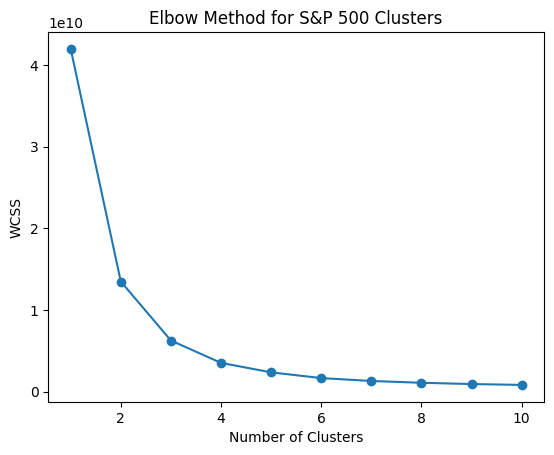

In [122]:
#now we try to perform some more clustering to see if we get any different behaviour
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize
import pandas as pd

predictors = ['gdp_growth', 'inflation', 'Market_Cap',
       'Dividend_Profit_After_Tax', 'Op_Cash_Flow_Ratio',
       'Price_to_Earnings', 'Price_to_Sales', 'Current_Ratio',
       'Rtrn_On_Assets', 'Rtrn_On_Cptl_Emplyd', 'Rtrn_On_Equity',
       'Debt_to_Asset', 'Debt_to_Equity', 'Interest_Coverage',
       'Fixed_Asset_Turnover', 'Book_Value_Per_Share', 'Sales_to_Cash_Flow',
       'Net_Sales_Increase', 'Cash_EPS', 'Price_to_Cash_Earnings', 'PBITDS',
       'Sales_to_Net_Assets']

df_analysis_winsorized = df_analysis
for col in predictors:
    df_analysis_winsorized[col] = winsorize(df_analysis[col], limits=[0.01, 0.01])

# Use the standardized features we prepared earlier
X = df_analysis_winsorized[['gdp_growth', 'inflation', 'Market_Cap',
       'Dividend_Profit_After_Tax', 'Op_Cash_Flow_Ratio',
       'Price_to_Earnings', 'Price_to_Sales', 'Current_Ratio',
       'Rtrn_On_Assets', 'Rtrn_On_Cptl_Emplyd', 'Rtrn_On_Equity',
       'Debt_to_Asset', 'Debt_to_Equity', 'Interest_Coverage',
       'Fixed_Asset_Turnover', 'Book_Value_Per_Share', 'Sales_to_Cash_Flow',
       'Net_Sales_Increase', 'Cash_EPS', 'Price_to_Cash_Earnings', 'PBITDS',
       'Sales_to_Net_Assets']]

wcss = [] # Within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for S&P 500 Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [124]:
#lets go with 4 clusters
# kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
df_analysis_winsorized['Cluster_ID'] = kmeans.fit_transform(X).argmin(axis=1)

# Check the sizes of your clusters
print(df_analysis_winsorized['Cluster_ID'].value_counts()) 

Cluster_ID
0    4692
3     991
2     256
1      94
Name: count, dtype: int64


In [ ]:
df_analysis_winsorized